In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("nifty50_10years.csv")
df.head()

,Date,Close,High,Low,Open,Volume
0,08-03-2016,7485.299805,7527.149902,7442.149902,7486.399902,257000
1,09-03-2016,7531.799805,7539.000000,7424.299805,7436.100098,245100
2,10-03-2016,7486.149902,7547.100098,7447.399902,7545.350098,224700
3,11-03-2016,7510.200195,7543.950195,7460.600098,7484.850098,198700
4,14-03-2016,7538.750000,7583.700195,7515.049805,7542.600098,166900


In [3]:
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2464 entries, 0 to 2463
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2464 non-null   object 
 1   Close   2464 non-null   float64
 2   High    2464 non-null   float64
 3   Low     2464 non-null   float64
 4   Open    2464 non-null   float64
 5   Volume  2464 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 115.6+ KB


In [5]:
df.describe()

,Close,High,Low,Open,Volume
count,2464.000000,2464.000000,2464.000000,2464.000000,2.464000e+03
mean,15467.449281,15545.786886,15384.988224,15476.319868,3.399526e+05
std,5700.157532,5721.080742,5678.467993,5700.393836,1.898038e+05
min,7460.600098,7508.000000,7405.149902,7436.100098,0.000000e+00
25%,10595.587890,10638.212158,10545.862552,10611.250243,2.188000e+05
50%,14714.549800,14854.975100,14606.600100,14748.375000,2.831500e+05
75%,19528.762695,19590.162110,19470.537597,19542.912597,4.102750e+05
max,26328.550780,26373.199220,26210.050780,26333.699220,1.811000e+06


## changing the format of DATE

In [6]:
df['Date']=pd.to_datetime(df['Date'],format='%d-%m-%Y')
df=df.sort_values('Date')
df.set_index('Date', inplace=True)
df = df.asfreq('B')
df.fillna(method='ffill', inplace=True)
df.head()

C:\Users\aksha\AppData\Local\Temp\ipykernel_13888\3784701895.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


,Close,High,Low,Open,Volume
Date,,,,,
2016-03-08,7485.299805,7527.149902,7442.149902,7486.399902,257000.0
2016-03-09,7531.799805,7539.000000,7424.299805,7436.100098,245100.0
2016-03-10,7486.149902,7547.100098,7447.399902,7545.350098,224700.0
2016-03-11,7510.200195,7543.950195,7460.600098,7484.850098,198700.0
2016-03-14,7538.750000,7583.700195,7515.049805,7542.600098,166900.0


In [7]:
df.dtypes

Close     float64
High      float64
Low       float64
Open      float64
Volume    float64
dtype: object

In [8]:
df.describe()

,Close,High,Low,Open,Volume
count,2609.000000,2609.000000,2609.000000,2609.000000,2.609000e+03
mean,15447.059616,15525.067379,15364.841350,15455.680226,3.406534e+05
std,5695.836818,5716.543244,5674.338949,5695.330932,1.917475e+05
min,7460.600098,7508.000000,7405.149902,7436.100098,0.000000e+00
25%,10584.750000,10637.799800,10534.549800,10607.799800,2.192000e+05
50%,14675.700200,14788.250000,14559.000000,14716.450200,2.835000e+05
75%,19526.550780,19587.050780,19436.449220,19539.449220,4.105000e+05
max,26328.550780,26373.199220,26210.050780,26333.699220,1.811000e+06


## For outlier i have created boxplot 

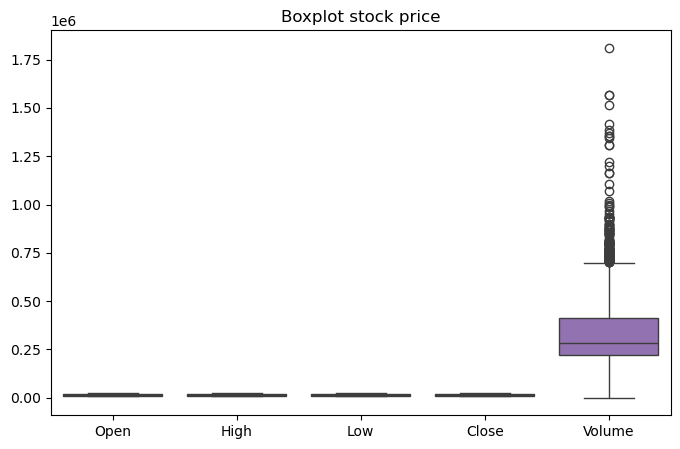

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['Open','High','Low','Close','Volume']])
plt.title("Boxplot stock price")
plt.show()

## Correlation Matrix

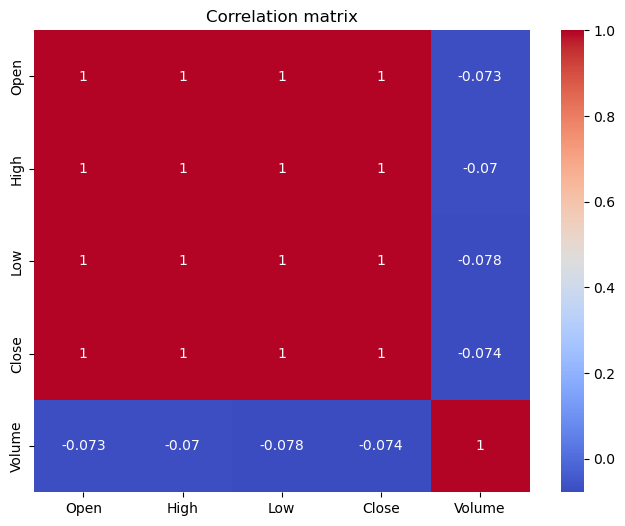

In [10]:
corr=df[['Open','High','Low','Close','Volume']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation matrix")
plt.show()

## price trend of nifty50

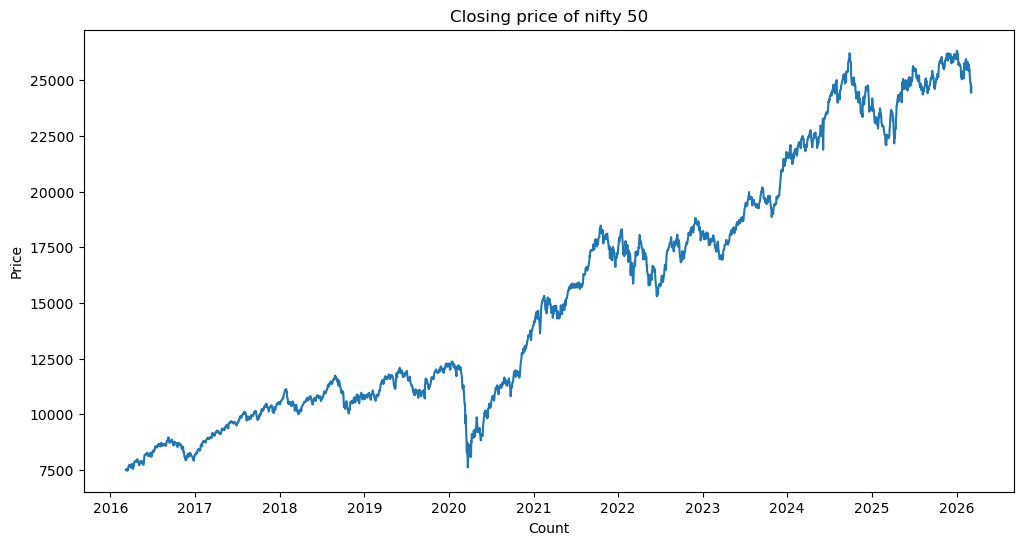

In [11]:
plt.figure(figsize=(12,6))
plt.plot(df.index,df['Close'])
plt.title("Closing price of nifty 50")
plt.xlabel("Count")
plt.ylabel("Price")
plt.show()

## before applying models,i create some variables likes(daily return, log return)

In [12]:
df['Return'] = df['Close'].pct_change()
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
df['Volatility'] = df['Return'].rolling(30).std()
df.dropna(inplace=True) #there is not missing value but it create automatically in the first row

## Daily Log Returns

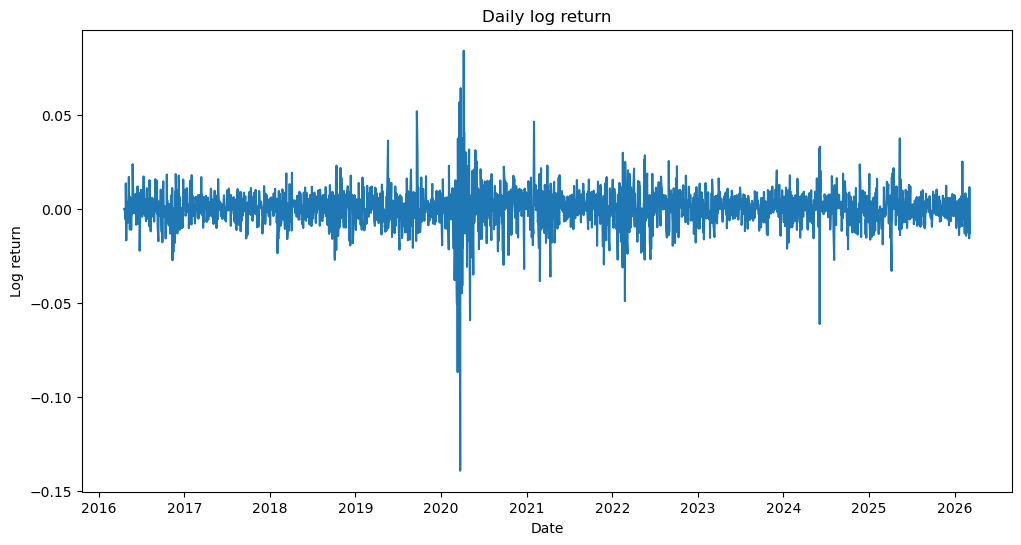

In [13]:
plt.figure(figsize=(12,6))
plt.plot(df.index,df['Log_Return'])
plt.title("Daily log return")
plt.xlabel("Date")
plt.ylabel("Log return")
plt.show()

## histogram graph of daily returns(how the returns of NIFTY50 are distributed)

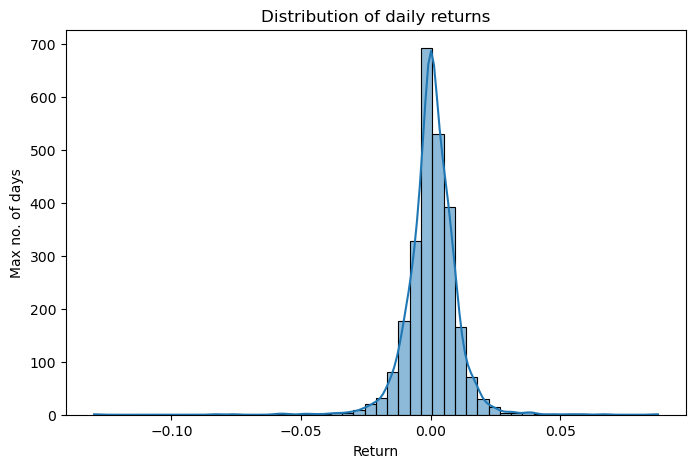

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['Return'], bins=50, kde=True)
plt.title("Distribution of daily returns")
plt.xlabel("Return")
plt.ylabel("Max no. of days")
plt.show()

## again before applying models,i have created one more variable rolling volatility(means how much returns fluctuate over time) for 30 days 

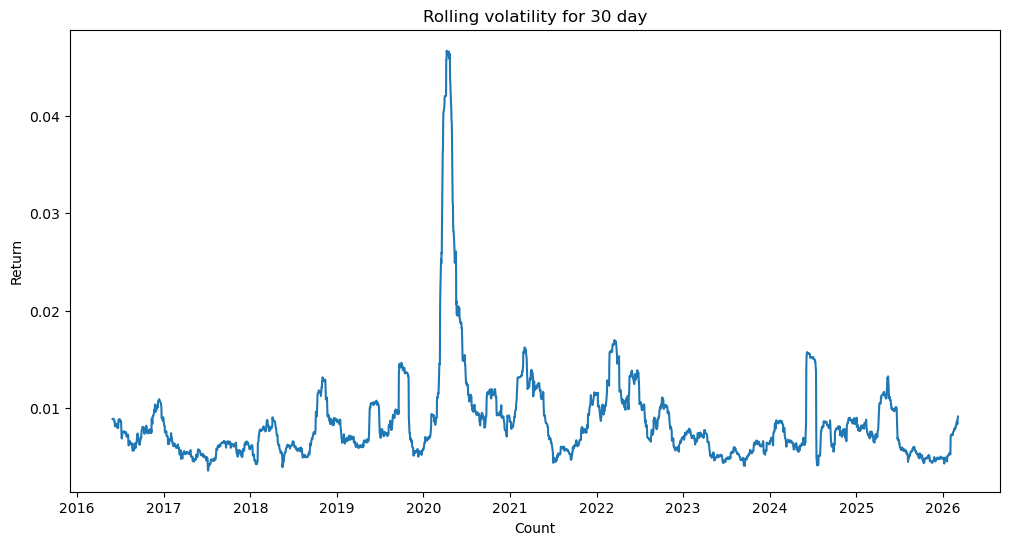

In [15]:
df['rolling_volatility'] = df['Return'].rolling(window=30).std()
plt.figure(figsize=(12,6))
plt.plot(df.index,df['rolling_volatility'])
plt.title("Rolling volatility for 30 day")
plt.xlabel("Count")
plt.ylabel("Return")
plt.show()

## ACF plot(autocorrelation plot)

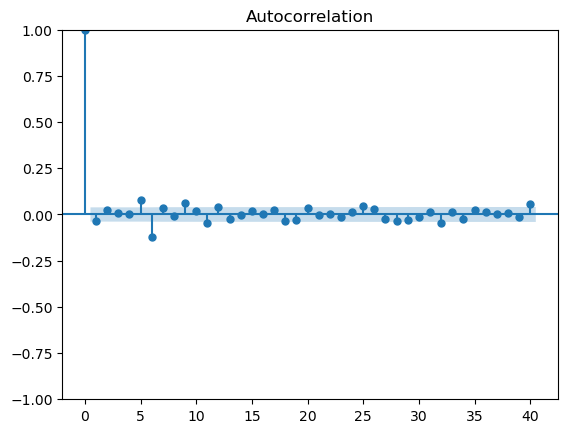

In [16]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(df['Return'].dropna(), lags=40)
plt.show()

## PACF plot

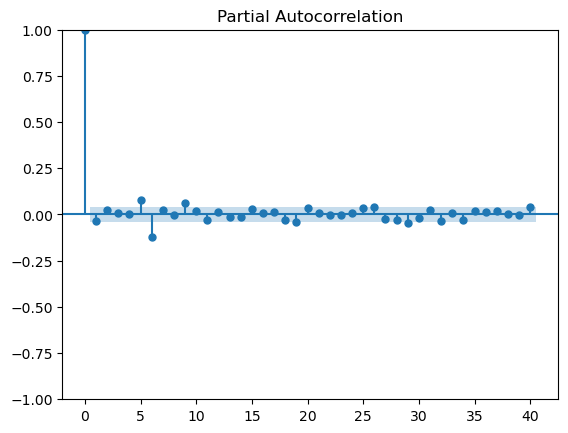

In [17]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(df['Return'].dropna(), lags=40)
plt.show()

## check whether the series is stationary using (ADF) test 

In [18]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df['Close'])
print("ADF statistic:", result[0])
print("p-value:", result[1])

ADF statistic: -0.41351666123546194
p-value: 0.9078174000124252


## now differencing the series

<Axes: xlabel='Date'>

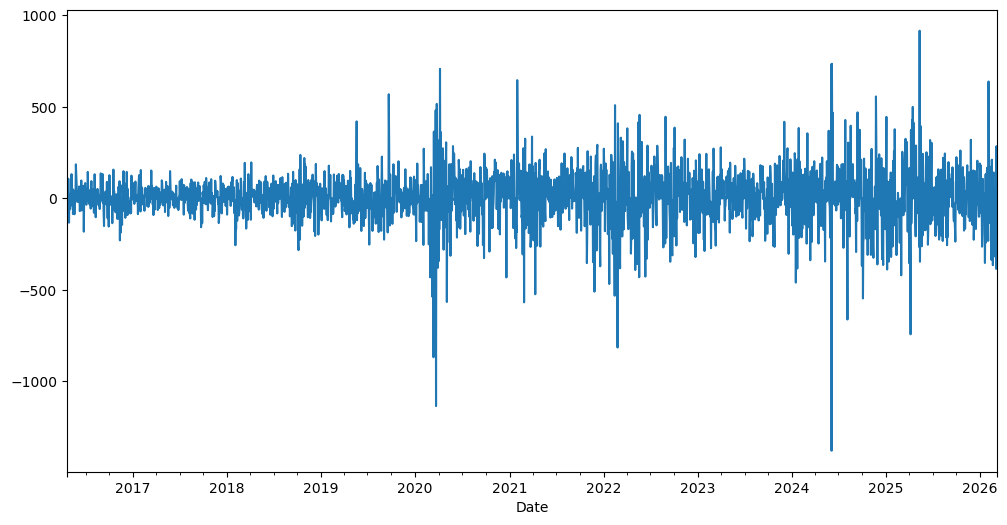

In [19]:
df['Close_diff']=df['Close'].diff()
df['Close_diff'].dropna().plot(figsize=(12,6))

## now i am spliting the dataset into two part that is "Train" and "Test"

In [20]:
train_size=int(len(df)*0.8)
train_return=df['Return'][:train_size]
test_return=df['Return'][train_size:]

## after that training the model on Return and i am applying the model that is (ARIMA model)

In [21]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
train_size = int(len(df) * 0.8)
train = df['Close'][:train_size]
test  = df['Close'][train_size:]
model_arima = ARIMA(train, order=(1,1,1))  # Close is non-stationary → d=1
result_arima = model_arima.fit()
pred_arima = result_arima.forecast(steps=len(test))

## now the summary of the ARIMA model

In [22]:
model=ARIMA(df['Return'], order=(1,1,1))
result=model.fit()
print(result.summary())

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                 Return   No. Observations:                 2579
Model:                 ARIMA(1, 1, 1)   Log Likelihood                8248.282
Date:                Wed, 20 May 2026   AIC                         -16490.564
Time:                        21:57:47   BIC                         -16472.999
Sample:                    04-19-2016   HQIC                        -16484.197
                         - 03-06-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0362      0.010     -3.711      0.000      -0.055      -0.017
ma.L1         -0.9998      0.015    -65.351      0.000      -1.030      -0.970
sigma2      9.701e-05    1.6e-06     60.565      0.0

## ARIMA Evaluation

In [23]:
rmse_arima = np.sqrt(mean_squared_error(test, pred_arima))
mae_arima  = mean_absolute_error(test, pred_arima)
print("ARIMA RMSE:", rmse_arima)
print("ARIMA MAE :", mae_arima)

ARIMA RMSE: 2512.314829164758
ARIMA MAE : 2231.4480809314896


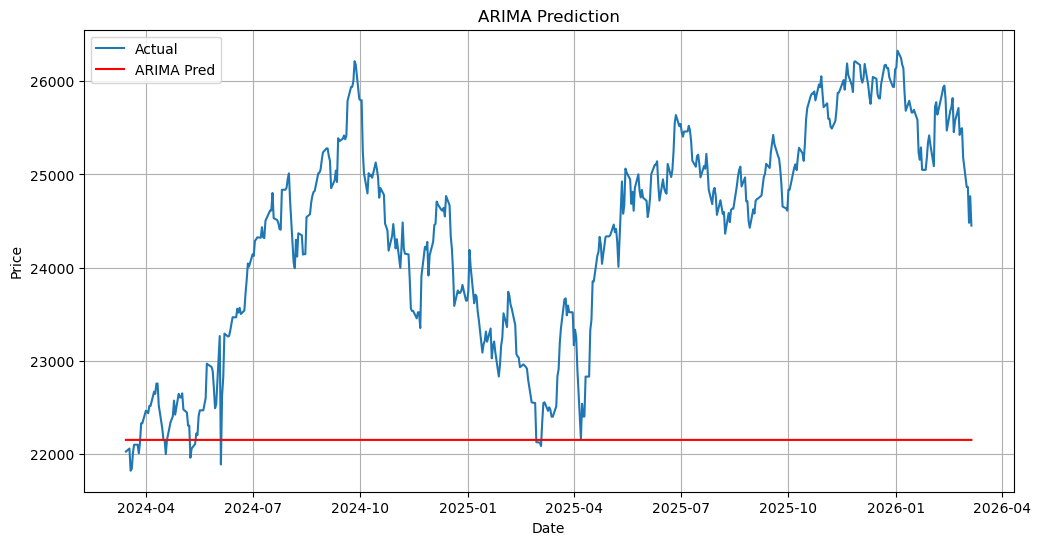

In [24]:
plt.figure(figsize=(12,6))
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, pred_arima, label="ARIMA Pred", color='red')
plt.title("ARIMA Prediction")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()


## Preparing Data for LSTM

In [25]:
from sklearn.preprocessing import StandardScaler
data = df[['Open','High','Low','Close']]
scaler = StandardScaler()
scaled = scaler.fit_transform(data)
scaled_df = pd.DataFrame(scaled, columns=data.columns, index=data.index)

## Creating Sequences

In [26]:
def create_sequences(data, time_steps=60):
    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i])
        y.append(data[i, 3])  # Close
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_df.values, 60)
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2519, 60, 4)
y shape: (2519,)


## Train-Test Split

In [27]:
split = int(len(X)*0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

## Now the model architecture for "LSTM"

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Input(shape=(60,4)),
    LSTM(50, return_sequences=True),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(25),
    Dense(1)])

model.compile(optimizer='adam', loss='mean_squared_error')
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - loss: 0.0396 - val_loss: 0.1196
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0098 - val_loss: 0.0294
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0094 - val_loss: 0.0088
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0081 - val_loss: 0.0093
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0070 - val_loss: 0.0360
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0068 - val_loss: 0.0103
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0062 - val_loss: 0.0393
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0066 - val_loss: 0.0076
Epoch 9/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 0.0061 - val_loss: 0.0052
Epoch 10/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.0059 - val_loss: 0.0048
Epoch 11/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 0.0070 - val_loss: 0.0063
Epoch 12/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0

## Loss Plot

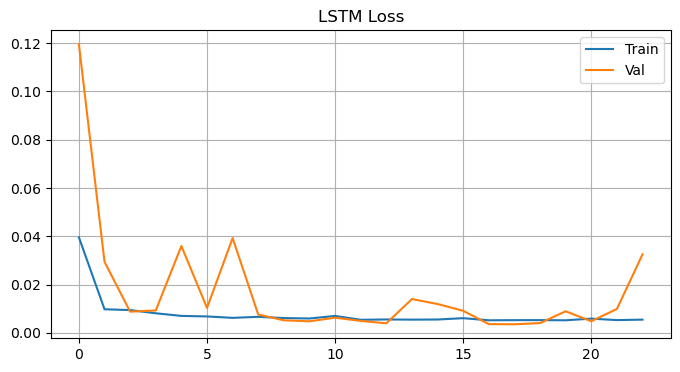

In [29]:
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title("LSTM Loss")
plt.legend()
plt.grid(True)
plt.show()

## Predictions

In [30]:
pred = model.predict(X_test)
dummy = np.zeros((len(pred), 4))
dummy[:,3] = pred.flatten()
predicted_price = scaler.inverse_transform(dummy)[:,3]
dummy[:,3] = y_test
actual_price = scaler.inverse_transform(dummy)[:,3]

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step 


## Evaluation

In [31]:
rmse = np.sqrt(mean_squared_error(actual_price, predicted_price))
mae  = mean_absolute_error(actual_price, predicted_price)
r2   = r2_score(actual_price, predicted_price)
print("LSTM RMSE:", rmse)
print("LSTM MAE :", mae)
print("R2 Score :", r2)

LSTM RMSE: 337.1616518718538
LSTM MAE : 273.0075975876128
R2 Score : 0.9108460921665001


## Now the final result through "Plot"

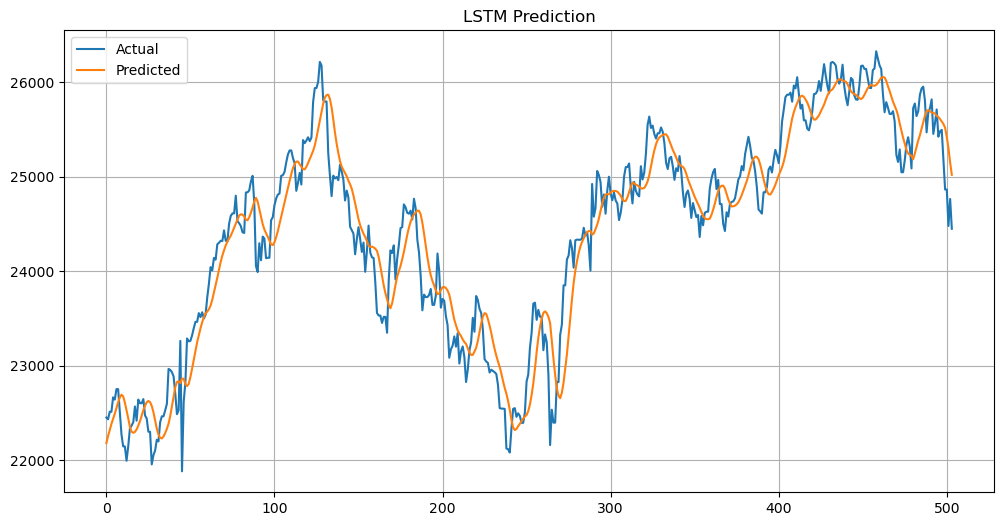

In [32]:
plt.figure(figsize=(12,6))
plt.plot(actual_price, label='Actual')
plt.plot(predicted_price, label='Predicted')
plt.title("LSTM Prediction")
plt.legend()
plt.grid(True)
plt.show()

## Buy /Sell plot signals

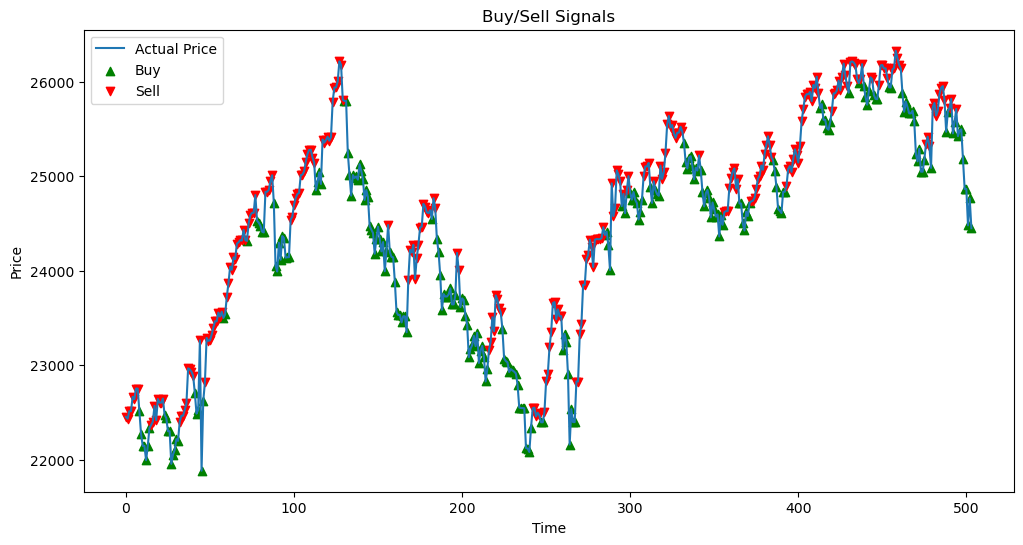

In [33]:
signals = np.where(predicted_price > actual_price, 1, -1)
plt.figure(figsize=(12,6))
plt.plot(actual_price, label='Actual Price')
buy = np.where(signals == 1)[0]
sell = np.where(signals == -1)[0]
plt.scatter(buy, actual_price[buy], color='green', marker='^', label='Buy')
plt.scatter(sell, actual_price[sell], color='red', marker='v', label='Sell')
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.title("Buy/Sell Signals")
plt.show()

## Buy /Sell signals threshold

In [34]:
threshold = 0.002
signals = np.where(
    (predicted_price - actual_price)/actual_price > threshold, 1,
    np.where(
        (predicted_price - actual_price)/actual_price < -threshold, -1, 0))

## Backtesting Strategy and Benchmark

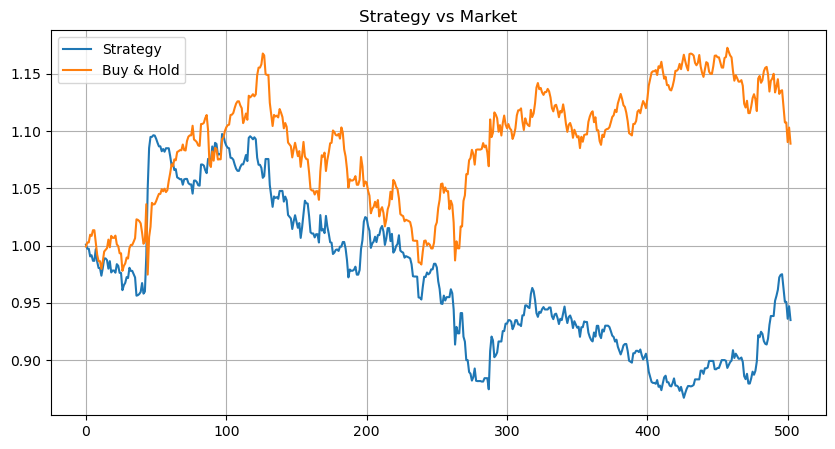

In [35]:
returns = np.diff(actual_price) / actual_price[:-1]
signals = signals[:-1]

strategy_returns = signals * returns
cum_strategy = np.cumprod(1 + strategy_returns)
buy_hold = np.cumprod(1 + returns)

plt.figure(figsize=(10,5))
plt.plot(cum_strategy, label="Strategy")
plt.plot(buy_hold, label="Buy & Hold")
plt.title("Strategy vs Market")
plt.legend()
plt.grid(True)
plt.show()

## Sharpe Ratio

In [36]:
sharpe = (np.mean(strategy_returns) / np.std(strategy_returns)) * np.sqrt(252)
print("Sharpe Ratio:", sharpe)

Sharpe Ratio: -0.21764323644770586


## Fututre Prediction after 6 month

In [37]:
future_days = 120
current_seq = X_test[-1].copy()
future_preds = []

for _ in range(future_days):
    p = model.predict(current_seq.reshape(1,60,4))
    future_preds.append(p[0,0])

    new_row = current_seq[-1].copy()
    new_row[3] = p[0,0]   # FIXED
    current_seq = np.vstack([current_seq[1:], new_row])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━

## Convert Future Prices

In [38]:
dummy = np.zeros((len(future_preds),4))
dummy[:,3] = future_preds
future_prices = scaler.inverse_transform(dummy)[:,3]

## Future Signals

In [39]:
future_signals=np.where(np.diff(future_prices) > 0, 1, -1)

## Plot Future Forecast

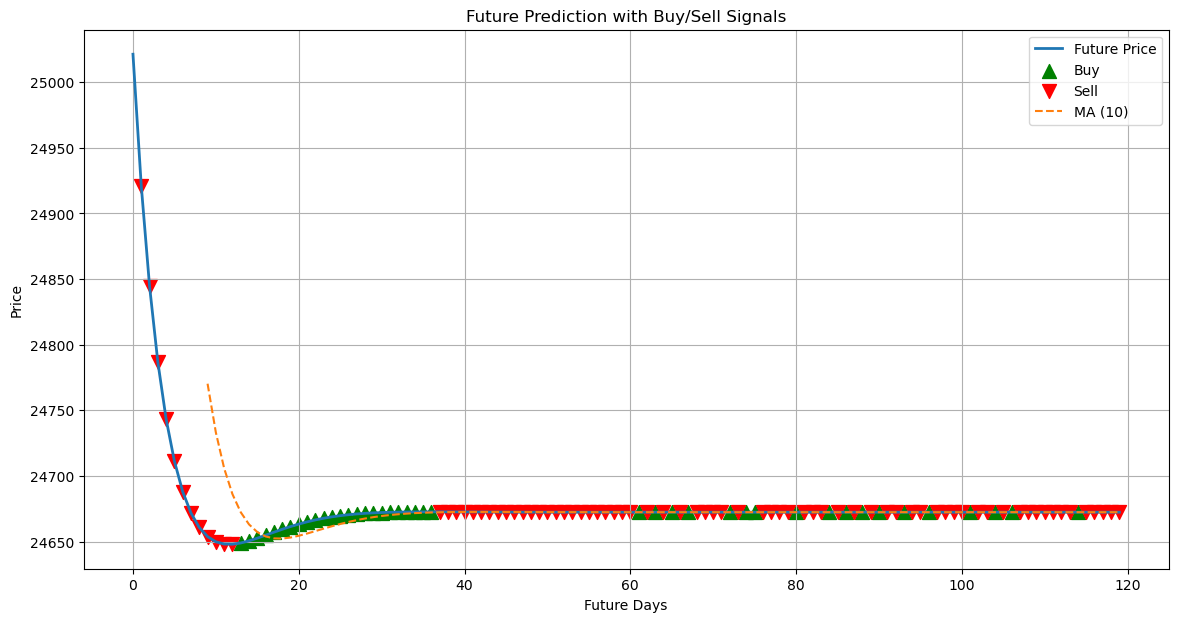

In [40]:
plt.figure(figsize=(14,7))

future_prices = np.array(future_prices)

# Price
plt.plot(future_prices, label='Future Price', linewidth=2)

# Signals
buy_idx = np.where(future_signals == 1)[0] + 1
sell_idx = np.where(future_signals == -1)[0] + 1

plt.scatter(buy_idx, future_prices[buy_idx], color='green', marker='^', s=100, label='Buy')
plt.scatter(sell_idx, future_prices[sell_idx], color='red', marker='v', s=100, label='Sell')

# Moving average
ma = pd.Series(future_prices).rolling(10).mean()
plt.plot(ma, linestyle='--', label='MA (10)')

plt.title("Future Prediction with Buy/Sell Signals")
plt.xlabel("Future Days")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

## Finding Shock Days

In [41]:
crisis_events= {"COVID Crash": ("2020-03-01", "2020-06-30"),
    "Russia-Ukraine War":("2022-02-24", "2022-03-31"),
    "Global Recession Fear": ("2022-06-01", "2022-10-31")}

df['shock']= 0
for event, (start, end) in crisis_events.items():
    mask = (df.index >= start) & (df.index <= end)
    df.loc[mask, 'shock'] = 1
    count = mask.sum()
    print(f"{event}: {start} → {end}  ({count} trading days marked)")

print(f"\nTotal shock days : {df['shock'].sum()}")
print(f"Total normal days: {(df['shock']==0).sum()}")

COVID Crash: 2020-03-01 → 2020-06-30  (87 trading days marked)
Russia-Ukraine War: 2022-02-24 → 2022-03-31  (26 trading days marked)
Global Recession Fear: 2022-06-01 → 2022-10-31  (109 trading days marked)

Total shock days : 222
Total normal days: 2357


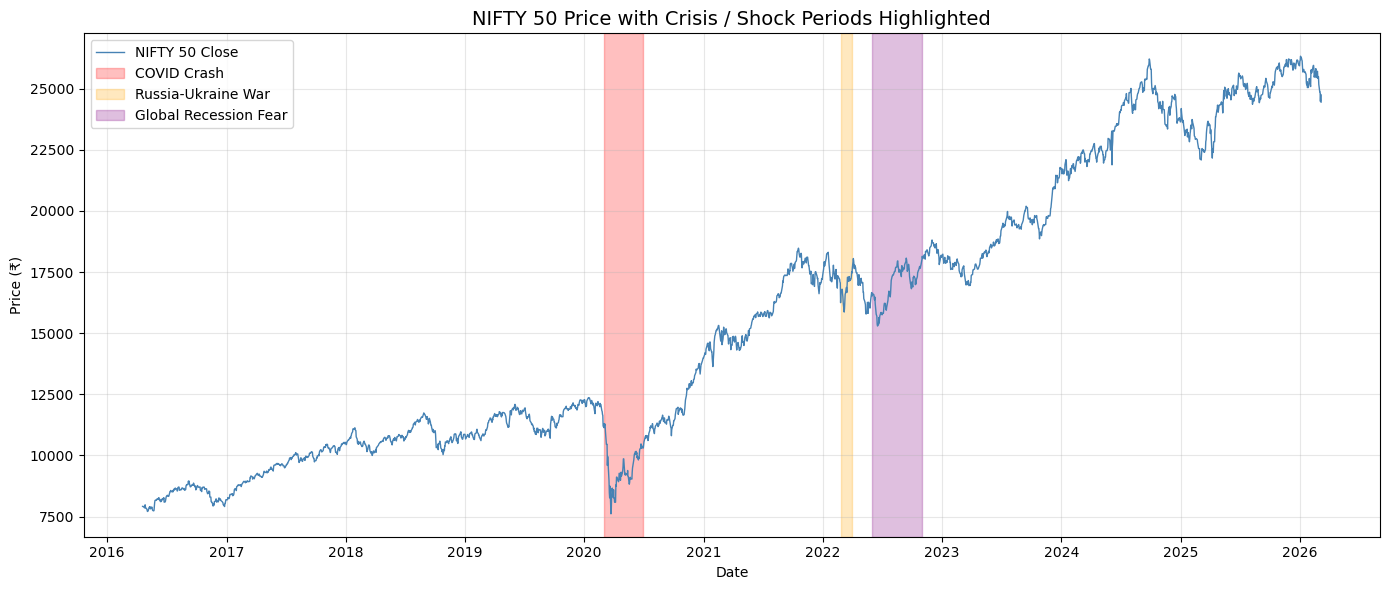

In [42]:
import matplotlib.patches as mpatches
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df['Close'], color='steelblue', linewidth=1, label='NIFTY 50 Close')
colors = ['red', 'orange', 'purple']
for i, (event, (start, end)) in enumerate(crisis_events.items()):
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
               alpha=0.25, color=colors[i], label=event)
ax.set_title("NIFTY 50 Price with Crisis / Shock Periods Highlighted", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Price (₹)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## ARIMAX

In [43]:
from statsmodels.tsa.arima.model import ARIMA

train_size_ax = int(len(df) * 0.8)
train_ax = df['Close'][:train_size_ax]
test_ax  = df['Close'][train_size_ax:]
shock_train = df['shock'][:train_size_ax]
shock_test  = df['shock'][train_size_ax:]

model_arimax = ARIMA(train_ax, order=(1, 1, 1), exog=shock_train)
result_arimax = model_arimax.fit()
pred_arimax = result_arimax.forecast(steps=len(test_ax), exog=shock_test)
print(result_arimax.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2063
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -12929.769
Date:                Wed, 20 May 2026   AIC                          25867.538
Time:                        21:59:41   BIC                          25890.064
Sample:                    04-19-2016   HQIC                         25875.796
                         - 03-14-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
shock       -235.4919     25.637     -9.186      0.000    -285.739    -185.244
ar.L1         -0.0511      1.371     -0.037      0.970      -2.739       2.637
ma.L1          0.0602      1.368      0.044      0.9

In [44]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse_arimax = np.sqrt(mean_squared_error(test_ax, pred_arimax))
mae_arimax  = mean_absolute_error(test_ax, pred_arimax)
mape_arimax = np.mean(np.abs((test_ax.values - pred_arimax.values) / test_ax.values)) * 100
print("ARIMAX Evaluation Metrics")
print(f"  RMSE : {rmse_arimax:.4f}")
print(f"  MAE  : {mae_arimax:.4f}")
print(f"  MAPE : {mape_arimax:.2f}%")

ARIMAX Evaluation Metrics
  RMSE : 2512.6613
  MAE  : 2231.8095
  MAPE : 8.95%


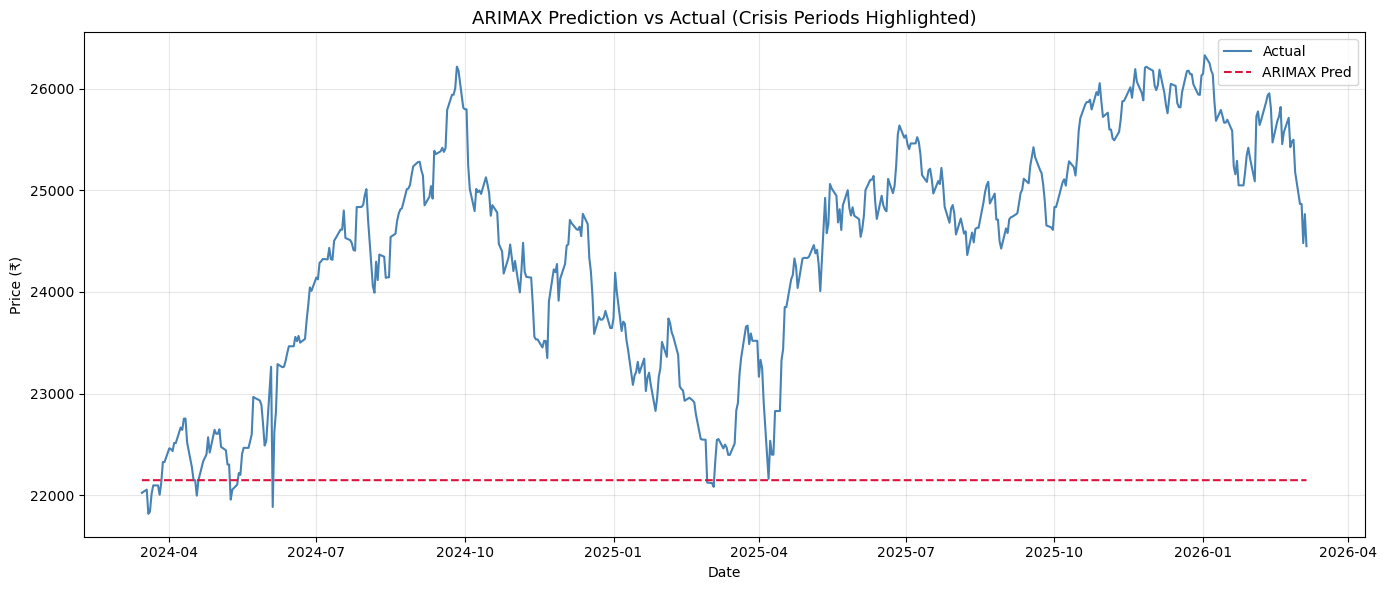

In [45]:
plt.figure(figsize=(14, 6))
plt.plot(test_ax.index, test_ax.values,label='Actual',color='steelblue')
plt.plot(test_ax.index, pred_arimax.values,label='ARIMAX Pred',color='crimson', linestyle='--')
for event, (start, end) in crisis_events.items():
    s, e = pd.Timestamp(start), pd.Timestamp(end)
    if s < test_ax.index[-1] and e > test_ax.index[0]:
        ax_shade_s = max(s, test_ax.index[0])
        ax_shade_e = min(e, test_ax.index[-1])
        plt.axvspan(ax_shade_s, ax_shade_e, alpha=0.2, color='orange', label=f'Crisis: {event}')
plt.title("ARIMAX Prediction vs Actual (Crisis Periods Highlighted)", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

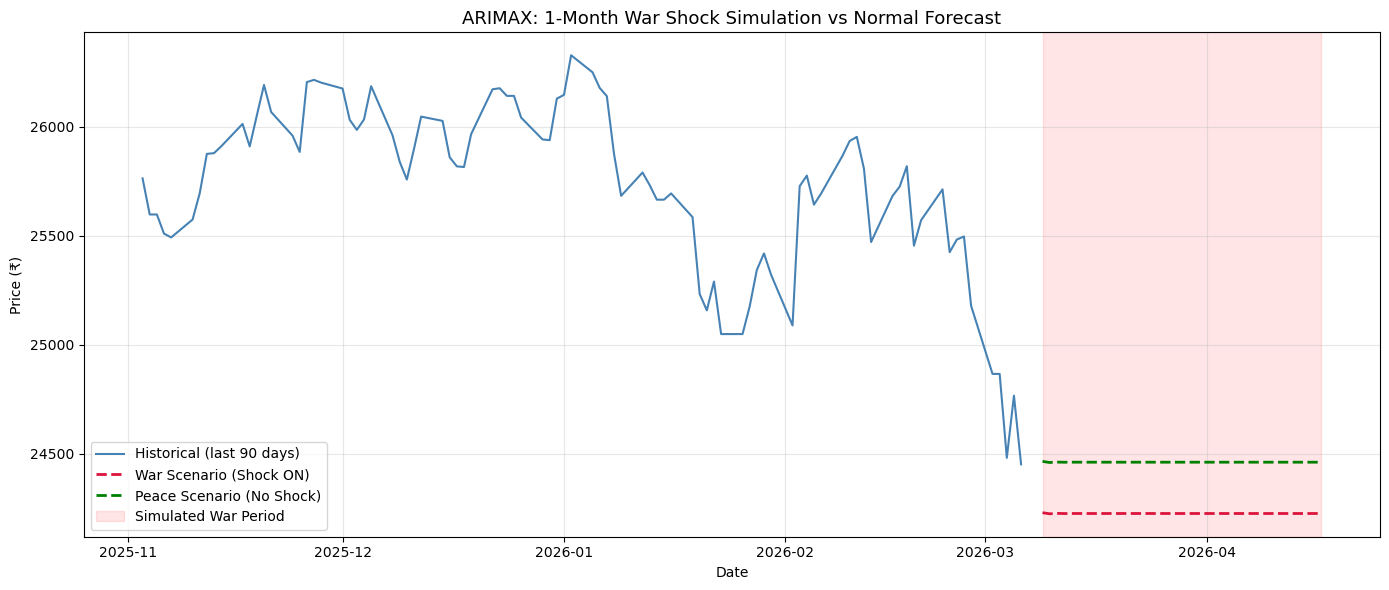

 Estimated price impact of war shock : ₹235.49 drop
 As percentage : 0.96% downward movement


In [46]:
future_shock_days = 30
future_exog_shock = np.ones(future_shock_days)
model_full_arimax = ARIMA(df['Close'], order=(1, 1, 1), exog=df['shock'])
result_full_arimax = model_full_arimax.fit()

forecast_war = result_full_arimax.forecast(steps=future_shock_days,exog=future_exog_shock)
future_exog_peace = np.zeros(future_shock_days)
forecast_peace = result_full_arimax.forecast(steps=future_shock_days,exog=future_exog_peace)
last_date   = df.index[-1]
future_dates = pd.bdate_range(start=last_date + pd.offsets.BDay(1),periods=future_shock_days)

plt.figure(figsize=(14, 6))
plt.plot(df.index[-90:], df['Close'].iloc[-90:],label='Historical (last 90 days)', color='steelblue', linewidth=1.5)
plt.plot(future_dates, forecast_war,label='War Scenario (Shock ON)',color='crimson',linewidth=2, linestyle='--')
plt.plot(future_dates, forecast_peace,label='Peace Scenario (No Shock)', color='green',    linewidth=2, linestyle='--')
plt.axvspan(future_dates[0], future_dates[-1], alpha=0.1, color='red', label='Simulated War Period')
plt.title("ARIMAX: 1-Month War Shock Simulation vs Normal Forecast", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

price_diff = forecast_peace.mean()-forecast_war.mean()
pct_drop   = (price_diff / forecast_peace.mean()) * 100
print(f" Estimated price impact of war shock : ₹{price_diff:.2f} drop")
print(f" As percentage : {pct_drop:.2f}% downward movement")

## GARCH MODEL

In [47]:
try:
    from arch import arch_model
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "arch", "-q"])
    from arch import arch_model
returns_pct = df['Return'].dropna() * 100
garch_model = arch_model(returns_pct, vol='Garch', p=1, q=1, dist='normal')
garch_result = garch_model.fit(disp='off')
print(garch_result.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3153.08
Distribution:                  Normal   AIC:                           6314.17
Method:            Maximum Likelihood   BIC:                           6337.59
                                        No. Observations:                 2579
Date:                Wed, May 20 2026   Df Residuals:                     2578
Time:                        21:59:43   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0704  1.619e-02      4.352  1.347e-05 [3.872e-0

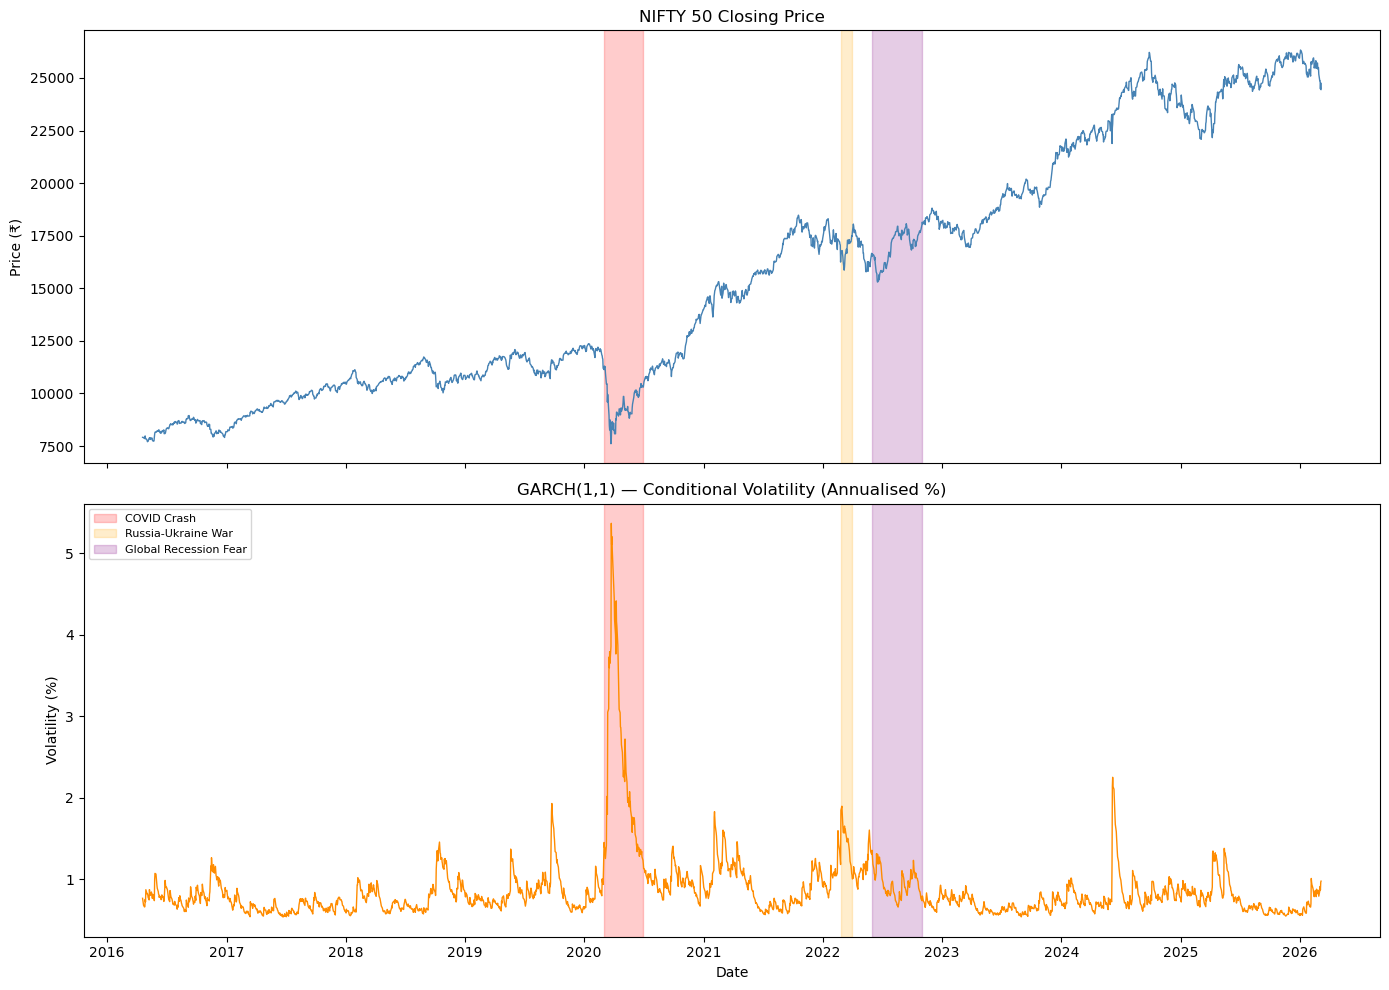


 Peak Volatility During Each Crisis Period:
--------------------------------------------------
  COVID Crash                   : 5.3699%
  Russia-Ukraine War            : 1.8962%
  Global Recession Fear         : 1.3134%


In [48]:
cond_vol = garch_result.conditional_volatility
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
axes[0].plot(df.index, df['Close'], color='steelblue', linewidth=1)
axes[0].set_title("NIFTY 50 Closing Price", fontsize=12)
axes[0].set_ylabel("Price (₹)")
axes[1].plot(cond_vol.index, cond_vol.values, color='darkorange', linewidth=1)
axes[1].set_title("GARCH(1,1) — Conditional Volatility (Annualised %)", fontsize=12)
axes[1].set_ylabel("Volatility (%)")
axes[1].set_xlabel("Date")
for ax in axes:
    for i, (event, (start, end)) in enumerate(crisis_events.items()):
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   alpha=0.2, color=colors[i], label=event)

axes[1].legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()
print("\n Peak Volatility During Each Crisis Period:")
print("-" * 50)
for event, (start, end) in crisis_events.items():
    peak = cond_vol.loc[start:end].max()
    print(f"  {event:30s}: {peak:.4f}%")

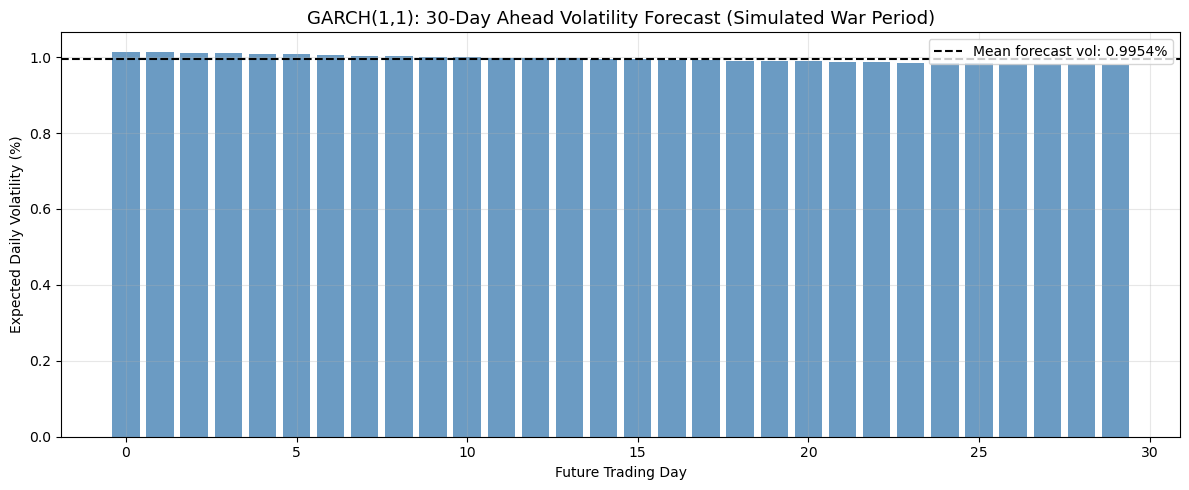


  Average forecast volatility : 0.9954%  →  MEDIUM RISK
  Peak forecast volatility    : 1.0145%
  Interpretation: During a 1-month war shock, daily price swings of
  ±1.99% to ±2.03% can be expected (2-sigma range)


In [49]:
horizon = 30
vol_forecast = garch_result.forecast(horizon=horizon, reindex=False)
forecast_variance= vol_forecast.variance.values[-1]
forecast_vol= np.sqrt(forecast_variance)
future_dates_g = pd.bdate_range(start=df.index[-1] + pd.offsets.BDay(1),periods=horizon)

plt.figure(figsize=(12, 5))
plt.bar(range(horizon), forecast_vol,
        color=['crimson' if v > forecast_vol.mean() * 1.2 else 'steelblue'
               for v in forecast_vol],alpha=0.8)
plt.axhline(forecast_vol.mean(), color='black', linestyle='--',linewidth=1.5, label=f'Mean forecast vol: {forecast_vol.mean():.4f}%')
plt.title("GARCH(1,1): 30-Day Ahead Volatility Forecast (Simulated War Period)", fontsize=13)
plt.xlabel("Future Trading Day")
plt.ylabel("Expected Daily Volatility (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

avg_vol    = forecast_vol.mean()
max_vol    = forecast_vol.max()
risk_level = "HIGH RISK" if avg_vol > 1.5 else ("MEDIUM RISK" if avg_vol > 0.8 else "LOW RISK")
print(f"\n  Average forecast volatility : {avg_vol:.4f}%  →  {risk_level}")
print(f"  Peak forecast volatility    : {max_vol:.4f}%")
print(f"  Interpretation: During a 1-month war shock, daily price swings of")
print(f"  ±{avg_vol*2:.2f}% to ±{max_vol*2:.2f}% can be expected (2-sigma range)")

## ANOMALY DETECTION

In [50]:
pip install IsolationForest

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


ERROR: Ignored the following versions that require a different python version: 1.0.0 Requires-Python ==2.7.*; 1.1.0 Requires-Python ==2.7.*
ERROR: Could not find a version that satisfies the requirement IsolationForest (from versions: none)
ERROR: No matching distribution found for IsolationForest


In [51]:
from sklearn.ensemble import IsolationForest
features = df[['Return', 'Log_Return', 'Volatility']].dropna().copy()
iso_forest = IsolationForest(n_estimators=200, contamination=0.02,random_state=42)
feature_cols = ['Return', 'Log_Return', 'Volatility']
features['anomaly'] = iso_forest.fit_predict(features[feature_cols])
features['anomaly_score'] = iso_forest.score_samples(features[feature_cols])
n_anomalies = (features['anomaly'] == -1).sum()
print(f"  Total anomalous days detected : {n_anomalies}")
print(f"  Total normal days: {(features['anomaly'] == 1).sum()}")
print(f"  Anomaly rate: {n_anomalies/len(features)*100:.2f}%")

  Total anomalous days detected : 52
  Total normal days: 2527
  Anomaly rate: 2.02%


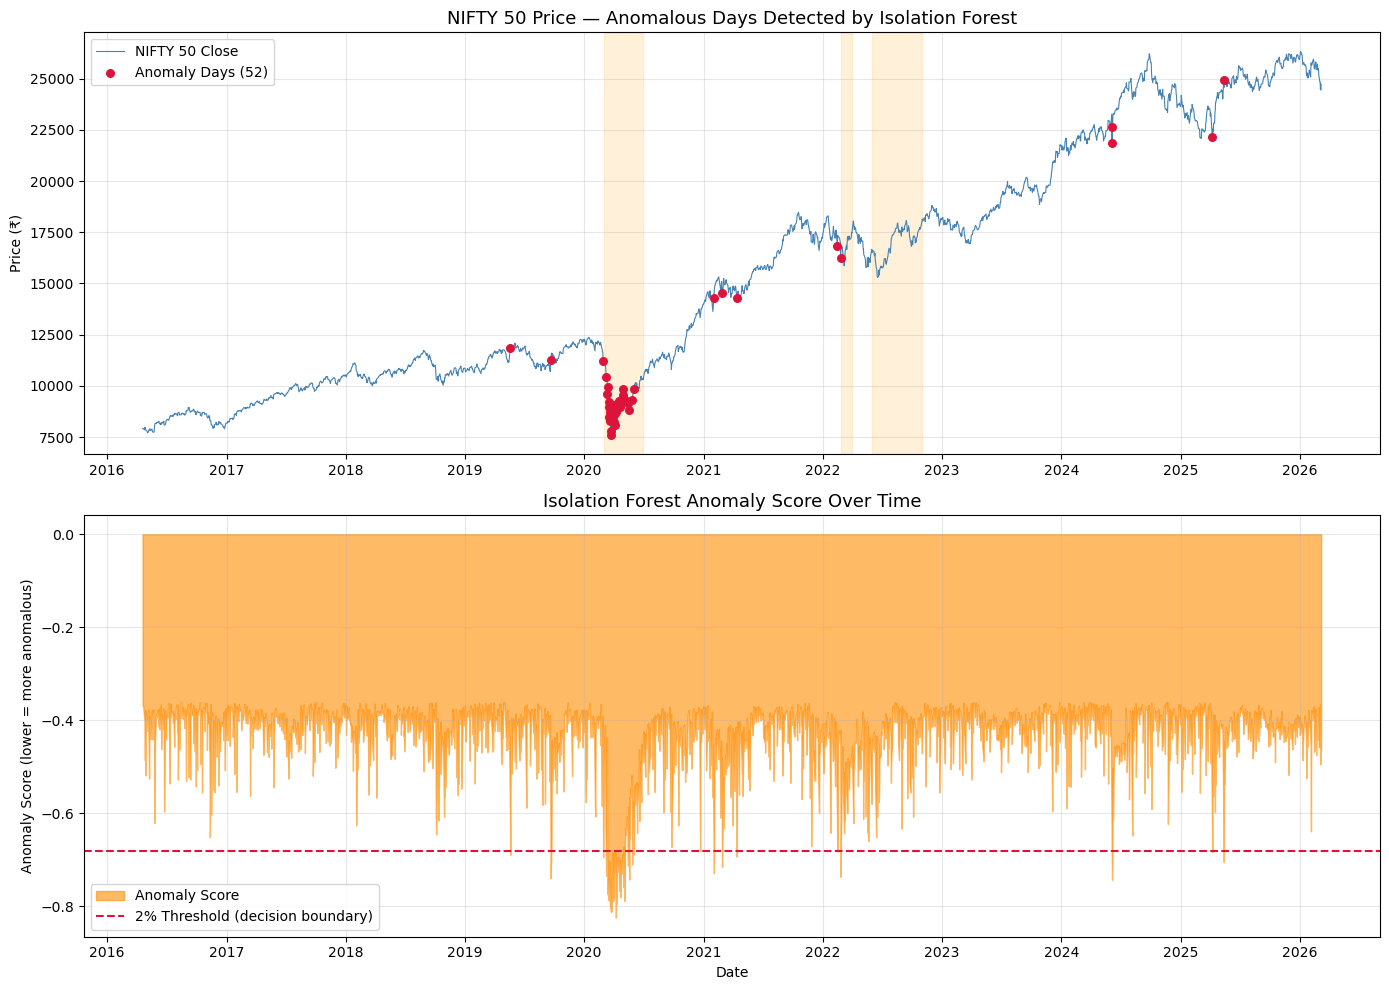

In [52]:
close_aligned = df['Close'].loc[features.index]
anomaly_idx = features[features['anomaly'] == -1].index
normal_idx  = features[features['anomaly'] ==  1].index
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
axes[0].plot(close_aligned.index, close_aligned.values,color='steelblue', linewidth=0.8, label='NIFTY 50 Close')
axes[0].scatter(anomaly_idx, close_aligned.loc[anomaly_idx],color='crimson', s=30, zorder=5, label=f'Anomaly Days ({n_anomalies})')
for event, (start, end) in crisis_events.items():
    axes[0].axvspan(pd.Timestamp(start), pd.Timestamp(end),alpha=0.15, color='orange')

axes[0].set_title("NIFTY 50 Price — Anomalous Days Detected by Isolation Forest", fontsize=13)
axes[0].set_ylabel("Price (₹)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].fill_between(features.index, features['anomaly_score'],alpha=0.6, color='darkorange', label='Anomaly Score')
axes[1].axhline(features['anomaly_score'].quantile(0.02),color='crimson', linestyle='--', linewidth=1.5,label='2% Threshold (decision boundary)')
axes[1].set_title("Isolation Forest Anomaly Score Over Time", fontsize=13)
axes[1].set_ylabel("Anomaly Score (lower = more anomalous)")
axes[1].set_xlabel("Date")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [53]:
print("Anomaly Detection Coverage of Known Crisis Periods:")
for event, (start, end) in crisis_events.items():
    period_days= features.loc[start:end]
    total= len(period_days)
    caught= (period_days['anomaly'] == -1).sum()
    pct= caught / total * 100 if total > 0 else 0
    print(f"  {event}")
    print(f"→ {caught}/{total} days flagged as anomalous ({pct:.1f}%)")
print()
print("High coverage = model correctly identifies the shock period")
print("even without being told the dates explicitly.")

Anomaly Detection Coverage of Known Crisis Periods:
  COVID Crash
→ 40/87 days flagged as anomalous (46.0%)
  Russia-Ukraine War
→ 1/26 days flagged as anomalous (3.8%)
  Global Recession Fear
→ 0/109 days flagged as anomalous (0.0%)

High coverage = model correctly identifies the shock period
even without being told the dates explicitly.


Simulated 1-Month War Period — Isolation Forest Results:
Anomalous days flagged : 19 / 30
Average anomaly score  : -0.6897



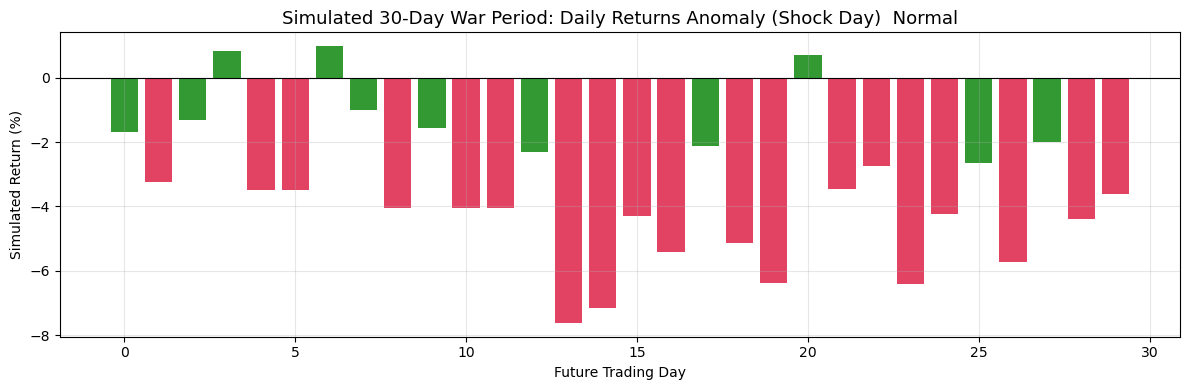

  Interpretation: 19/30 days during the simulated war are
  classified as ANOMALOUS — confirming the model detects the shock.


In [54]:
np.random.seed(42)
normal_return_mean= df['Return'].mean()
normal_return_std= df['Return'].std()
shock_return_mean= normal_return_mean-3*normal_return_std
shock_return_std= normal_return_std* 2.5

future_returns_war= np.random.normal(shock_return_mean, shock_return_std, 30)
future_log_war= np.log(1 + future_returns_war)
future_vol_war= pd.Series(future_returns_war).rolling(5, min_periods=1).std().values

future_df_war = pd.DataFrame({
    'Return'     : future_returns_war,
    'Log_Return' : future_log_war,
    'Volatility' : future_vol_war})
future_labels = iso_forest.predict(future_df_war)
future_scores  = iso_forest.score_samples(future_df_war)

flagged = (future_labels == -1).sum()
print(f"Simulated 1-Month War Period — Isolation Forest Results:")
print(f"Anomalous days flagged : {flagged} / 30")
print(f"Average anomaly score  : {future_scores.mean():.4f}")
print()
colors_flag = ['crimson' if l == -1 else 'green' for l in future_labels]
plt.figure(figsize=(12, 4))
plt.bar(range(30), future_returns_war * 100, color=colors_flag, alpha=0.8)
plt.axhline(0, color='black', linewidth=0.8)
plt.title("Simulated 30-Day War Period: Daily Returns Anomaly (Shock Day)  Normal", fontsize=13)
plt.xlabel("Future Trading Day")
plt.ylabel("Simulated Return (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"  Interpretation: {flagged}/30 days during the simulated war are")
print(f"  classified as ANOMALOUS — confirming the model detects the shock.")

In [55]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse_arima_orig = np.sqrt(mean_squared_error(test_ax, pred_arima[:len(test_ax)]))
mae_arima_orig  = mean_absolute_error(test_ax, pred_arima[:len(test_ax)])
summary_data = {
    "Model"       : ["ARIMA (baseline)", "ARIMAX (with shock flag)", "GARCH (volatility)", "Isolation Forest"],
    "Purpose"     : ["Price level forecast","Price forecast + crisis effect","Volatility / Risk forecast","Automatic anomaly detection"],
    "RMSE / Metric": [f"{rmse_arima_orig:.2f}",f"{rmse_arimax:.2f}",f"Avg vol: {avg_vol:.4f}%",f"{flagged}/30 war days flagged"],
    "Crisis Aware?": ["No", "Yes", "Yes", "Yes"]}
summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print()
print(f"ARIMAX estimated price drop during 1-month war : {pct_drop:.2f}%")
print(f"GARCH peak volatility forecast : {max_vol:.4f}%")
print(f"Isolation Forest war day detection rate: {flagged/30*100:.1f}%")

                   Model                        Purpose          RMSE / Metric Crisis Aware?
        ARIMA (baseline)           Price level forecast                2512.31            No
ARIMAX (with shock flag) Price forecast + crisis effect                2512.66           Yes
      GARCH (volatility)     Volatility / Risk forecast       Avg vol: 0.9954%           Yes
        Isolation Forest    Automatic anomaly detection 19/30 war days flagged           Yes

ARIMAX estimated price drop during 1-month war : 0.96%
GARCH peak volatility forecast : 1.0145%
Isolation Forest war day detection rate: 63.3%
